# Forest Carbon Stock Change Estimation
## Little Andaman Island, India | 2020-2025

This notebook extends the 2020-2022 pilot to a full 5-year window, pairing NASA GEDI LiDAR footprints with ESA Sentinel-2 optical composites to estimate above-ground biomass density (AGBD) change on Little Andaman Island. A Gradient Boosting model trained on GEDI footprint-level biomass measurements is applied wall-to-wall across the island using Sentinel-2 as a spatial scaffold, then cross-checked against a footprint-only bootstrap that does not depend on spatial interpolation.

**Primary purpose:** Extend the reproducible GEDI-Sentinel-2 fusion pipeline to a longer time baseline and add landscape-level uncertainty quantification, since the 2025 GEDI acquisition has notably sparser coverage than 2020.

**Study area:** Little Andaman Island, Andaman Islands, India (approx. 734 sq km, over 93% intact tropical forest)
**Data sources:** NASA GEDI L4A v2.1 + L2A v2 | ESA Sentinel-2 L2A
**Pipeline:** GEDI Harmony API -> OpenEO -> HDF5 extraction -> 12.5m buffer zonal fusion -> GBR model -> carbon accounting -> bootstrap uncertainty
**Methodology reference:** IPCC 2006 Guidelines | Verra VM0048 (REDD+) | VT0005 (remote sensing biomass)

## 00 - Configuration & Imports

In [10]:
import os
import json
import h5py
import joblib
import requests as re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import openeo
import earthaccess as ea 
import contextily as ctx
from shapely.geometry import box
from pathlib import Path
from datetime import datetime, date
from dateutil.relativedelta import relativedelta
from concurrent.futures import TimeoutError
from scipy.spatial import cKDTree
from harmony import Client, Collection, Request, BBox
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

In [2]:
# Creating project root and subdirectories:
PROJECT_ROOT = Path(__file__).resolve().parent if '__file__' in dir() else Path.cwd()

DATA_DIR   = PROJECT_ROOT / 'data'
GEDI_DIR   = DATA_DIR    / 'gedi'
S2_DIR     = DATA_DIR    / 'sentinel_2'
OUTPUT_DIR = PROJECT_ROOT / 'output'
MODEL_DIR  = PROJECT_ROOT / 'model'
FIGURES_DIR = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, GEDI_DIR, S2_DIR, OUTPUT_DIR, MODEL_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Study area: Little Andaman Island (lon_min, lat_min, lon_max, lat_max)
BBOX = (92.303245, 10.504269, 92.665951, 10.937400)

# Acquisition windows - Jan–Apr dry season minimises cloud cover
PERIOD_1 = ('2020-01-01', '2020-04-30')
PERIOD_2 = ('2025-01-01', '2025-04-30')

BEAMS = [
    'BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011',
    'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011',
]

# Feature order must be preserved consistently across training and prediction
FEATURES = [
    'rh98',
    'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
    'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2',
]
TARGET       = 'agbd'
RANDOM_STATE = 42

# Carbon conversion constants (IPCC 2006 defaults for tropical forest)
CARBON_FRACTION = 0.47   # fraction of dry biomass that is carbon
C_TO_CO2        = 44/12  # molecular weight ratio C -> CO2
PIXEL_AREA_HA   = 0.01   # 10m x 10m = 0.01 ha

print(f'Project root:    {PROJECT_ROOT}')
print(f'Study area bbox: {BBOX}')
print(f'Period 1:        {PERIOD_1[0]} - {PERIOD_1[1]}')
print(f'Period 2:        {PERIOD_2[0]} - {PERIOD_2[1]}')
print(f'Directories OK:  {[d.name for d in [DATA_DIR, GEDI_DIR, S2_DIR, OUTPUT_DIR, MODEL_DIR, FIGURES_DIR]]}')

Project root:    c:\Users\simra\Documents\Carbon credit estimation project
Study area bbox: (92.303245, 10.504269, 92.665951, 10.9374)
Period 1:        2020-01-01 - 2020-04-30
Period 2:        2025-01-01 - 2025-04-30
Directories OK:  ['data', 'gedi', 'sentinel_2', 'output', 'model', 'figures']


## 01 - GEDI Data Acquisition

GEDI (Global Ecosystem Dynamics Investigation) is a spaceborne LiDAR that profiles forest canopy structure along ISS orbital tracks. Two products feed this analysis:

- **L4A**: footprint-level AGBD (Mg/ha), the prediction target
- **L2A**: rh98 (98th percentile relative height), the primary predictor

Both are pulled through NASA's Harmony API, which subsets each HDF5 granule to the Little Andaman bounding box before download (roughly 5-20 MB per file versus about 1 GB for a full global granule). L4A downloads in a single annual request; L2A is batched by month because Harmony's L2A subsetter times out on larger temporal spans.

Acquisition window: January-April in both 2020 and 2025, keeping dry-season, low-cloud conditions consistent across the 5-year gap. One of the ten 2025 granule pairs was not available through the subsetter, which is the direct cause of the sparser 2025 shot count seen in the track coverage plot below.

In [3]:
# Connecting with Harmony and getting Concept ID for L2A and L4A
harmony_client = Client()

def get_concept_id(doi):
    url = f'https://cmr.earthdata.nasa.gov/search/collections.json?doi={doi}'
    return re.get(url).json()['feed']['entry'][0]['id']

CONCEPT_L4A = get_concept_id('10.3334/ORNLDAAC/2056')
CONCEPT_L2A = get_concept_id('10.5067/GEDI/GEDI02_A.002')

print(f'L2A Concept ID: {CONCEPT_L2A}')
print(f'L4A Concept ID: {CONCEPT_L4A}')

def beam_vars(variables):
    """Build per-beam variable paths for Harmony subsetting."""
    return [f'/{b}/{v}' for b in BEAMS for v in variables]

VARS_L4A = beam_vars([
    'agbd', 'l4_quality_flag', 'lat_lowestmode', 'lon_lowestmode',
    'land_cover_data/pft_class'
])
VARS_L2A = beam_vars(['rh', 'lat_lowestmode', 'lon_lowestmode'])

HARMONY_BBOX = BBox(w=BBOX[0], s=BBOX[1], e=BBOX[2], n=BBOX[3])

L2A Concept ID: C2142771958-LPCLOUD
L4A Concept ID: C2237824918-ORNL_CLOUD


In [4]:
def download_l4a(period, out_dir, label):
    """Download GEDI L4A for a given period via Harmony as a single request."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    start = datetime.strptime(period[0], '%Y-%m-%d')
    stop  = datetime.strptime(period[1], '%Y-%m-%d')
    request = Request(
        collection=Collection(id=CONCEPT_L4A),
        variables=VARS_L4A,
        temporal={'start': start, 'stop': stop},
        spatial=HARMONY_BBOX,
        ignore_errors=True,
    )
    job_id = harmony_client.submit(request)
    print(f'[{label} L4A] Job: {job_id}')
    harmony_client.result_json(job_id, show_progress=True)
    files = []
    futures = harmony_client.download_all(job_id, directory=str(out_dir), overwrite=False)
    for f in futures:
        try:
            result = f.result(timeout=120)
            if result and result.endswith('subsetted.h5'):
                print(f'  OK: {Path(result).name}')
                files.append(result)
        except TimeoutError:
            print('  TIMEOUT - skipping')
        except Exception as e:
            print(f'  ERROR: {e}')
    print(f'[{label} L4A] {len(files)} files downloaded.')
    return files


def download_l2a(period, out_dir, label):
    """
    Download GEDI L2A in monthly batches.

    The Harmony L2A subsetter hangs on multi-month requests - monthly batching
    keeps each job small enough to complete within the timeout window.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    start   = datetime.strptime(period[0], '%Y-%m-%d')
    stop    = datetime.strptime(period[1], '%Y-%m-%d')
    windows = []
    current = start
    while current <= stop:
        month_end = min(current + relativedelta(months=1) - relativedelta(days=1), stop)
        windows.append((current, month_end))
        current += relativedelta(months=1)
    files = []
    for w_start, w_stop in windows:
        month_label = w_start.strftime('%b %Y')
        print(f'  [{label} L2A] {month_label}')
        try:
            request = Request(
                collection=Collection(id=CONCEPT_L2A),
                variables=VARS_L2A,
                temporal={'start': w_start, 'stop': w_stop},
                spatial=HARMONY_BBOX,
                ignore_errors=True,
            )
            job_id  = harmony_client.submit(request)
            harmony_client.result_json(job_id, show_progress=False)
            futures = harmony_client.download_all(job_id, directory=str(out_dir), overwrite=False)
            for f in futures:
                try:
                    result = f.result(timeout=180)
                    if result and result.endswith('subsetted.h5'):
                        print(f'    OK: {Path(result).name}')
                        files.append(result)
                except TimeoutError:
                    print('    TIMEOUT - skipping')
                except Exception as e:
                    print(f'    ERROR: {e}')
        except Exception as e:
            print(f'    Job failed: {e} - skipping {month_label}')
    print(f'[{label} L2A] {len(files)} files downloaded.')
    return files

## 02 - GEDI Preprocessing & Quality Filtering

Both years go through the same extraction and quality-filtering logic (`read_l2a`, `read_l4a`, Section 00), so results stay comparable across the 5-year gap rather than being an artifact of different processing per year.

**Extraction:** L4A yields AGBD, quality flag, coordinates, and PFT class; L2A yields rh98 (index 98 of the relative height array) and coordinates. The two are joined on lat/lon rounded to 6 decimal places (about 0.1m), matching footprints without a spatial join.

**Quality filters:**
- `l4_quality_flag == 1`: high-quality AGBD retrievals only
- `pft_class` 1-5: trees and shrubs, excluding water, urban, and bare ground
- `0 < agbd < 600` Mg/ha: physically plausible range for tropical forest

Corrupt HDF5 files are caught and skipped automatically.

In [5]:
def read_l2a(files):
    """Extract rh98 and coordinates from L2A subsetted HDF5 files."""
    records = []
    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'rh' not in b or 'lat_lowestmode' not in b:
                        continue
                    if b['lat_lowestmode'].shape[0] == 0:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]
                    rh  = b['rh'][:]
                    records.append(pd.DataFrame({
                        'lat_key': np.round(lat, 6),
                        'lon_key': np.round(lon, 6),
                        'rh98':    rh[:, 98],
                        'rh100':   rh[:, 100],
                    }))
        except OSError:
            print(f'  CORRUPT: {Path(fpath).name} - skipping')
    df = pd.concat(records, ignore_index=True)
    return df.drop_duplicates(subset=['lat_key', 'lon_key'])


def read_l4a(files):
    """Extract AGBD and coordinates from L4A subsetted HDF5 files."""
    records = []
    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'agbd' not in b or 'lat_lowestmode' not in b:
                        continue
                    if b['lat_lowestmode'].shape[0] == 0:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]
                    records.append(pd.DataFrame({
                        'lat_key':         np.round(lat, 6),
                        'lon_key':         np.round(lon, 6),
                        'lat':             lat,
                        'lon':             lon,
                        'agbd':            b['agbd'][:],
                        'l4_quality_flag': b['l4_quality_flag'][:],
                        'pft_class':       b['land_cover_data/pft_class'][:],
                    }))
        except OSError:
            print(f'  CORRUPT: {Path(fpath).name} - skipping')
    return pd.concat(records, ignore_index=True)


def build_gedi_gdf(l4a_files, l2a_files, label):
    """
    Join L4A and L2A on footprint coordinates, apply quality filters,
    and return a clean GeoDataFrame.

    Join key: lat/lon rounded to 6 decimal places (~0.1m precision).
    Quality filters: l4_quality_flag == 1, pft_class 1-5, 0 < agbd < 600.
    """
    print(f'[{label}] Reading L4A...')
    l4a = read_l4a(l4a_files)
    print(f'  L4A shots loaded: {len(l4a):,}')

    print(f'[{label}] Reading L2A...')
    l2a = read_l2a_subset(l2a_files, BBOX)
    print(f'  L2A shots loaded: {len(l2a):,}')

    print(f'[{label}] Joining on lat/lon key...')
    merged = l4a.merge(
        l2a[['lat_key', 'lon_key', 'rh98', 'rh100']],
        on=['lat_key', 'lon_key'], how='inner'
    )
    print(f'  After join: {len(merged):,}')

    mask = (
        (merged['l4_quality_flag'] == 1) &
        (merged['pft_class'].between(1, 5)) &
        (merged['agbd'] > 0) &
        (merged['agbd'] < 600)
    )
    clean = merged[mask].drop_duplicates(subset=['lat_key', 'lon_key']).copy()
    print(f'  After QC + dedup: {len(clean):,}')
    print(f'  AGBD mean: {clean["agbd"].mean():.1f} Mg/ha')
    print(f'  rh98 mean: {clean["rh98"].mean():.1f} m')

    return gpd.GeoDataFrame(
        clean,
        geometry=gpd.points_from_xy(clean['lon'], clean['lat']),
        crs='EPSG:4326'
    )

In [6]:
# Run once — skip if data already downloaded
#l4a_files_2020 = download_l4a(PERIOD_1, GEDI_DIR / '2020', '2020')
#l4a_files_2025 = download_l4a(PERIOD_2, GEDI_DIR / '2025', '2025')

#l2a_files_2020 = download_l2a(PERIOD_1, GEDI_DIR / '2020', '2020')
#l2a_files_2025 = download_l2a(PERIOD_2, GEDI_DIR / '2025', '2025')

In [12]:

ea.login(strategy='netrc')  # or 'interactive' if netrc not set up

def download_l2a_direct(period, out_dir, label):
    """
    Download L2A granules directly via earthaccess (ea) (bypasses Harmony subsetter).
    Files are full orbit granules — we subset to bbox manually after download.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    results = ea.search_data(
        concept_id = CONCEPT_L2A,
        temporal   = (period[0], period[1]),
        bounding_box = BBOX,  # (west, south, east, north)
    )
    print(f"[{label} L2A] {len(results)} granules found")

    files = ea.download(results, local_path=str(out_dir))
    print(f"[{label} L2A] {len(files)} files downloaded")
    return [str(f) for f in files]


def read_l2a_subset(files, bbox):
    """
    Read L2A files and spatially subset to bbox manually.
    Replaces the Harmony-subsetted read_l2a() function.
    bbox = (west, south, east, north)
    """
    west, south, east, north = bbox
    records = []

    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'rh' not in b or 'lat_lowestmode' not in b:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]

                    # Spatial subset — this is what Harmony was doing server-side
                    mask = (
                        (lat >= south) & (lat <= north) &
                        (lon >= west)  & (lon <= east)
                    )
                    if mask.sum() == 0:
                        continue

                    rh = b['rh'][:]
                    records.append(pd.DataFrame({
                        'lat_key': np.round(lat[mask], 6),
                        'lon_key': np.round(lon[mask], 6),
                        'rh98':    rh[mask, 98],
                        'rh100':   rh[mask, 100],
                    }))
                    print(f"  {beam}: {mask.sum()} shots in bbox")

        except OSError:
            print(f"  CORRUPT: {Path(fpath).name} — skipping")

    if not records:
        print("  WARNING: no shots found in bbox across all files")
        return pd.DataFrame(columns=['lat_key', 'lon_key', 'rh98', 'rh100'])

    df = pd.concat(records, ignore_index=True)
    df = df.drop_duplicates(subset=['lat_key', 'lon_key'])
    print(f"  Total after dedup: {len(df):,} shots")
    return df

In [13]:
l4a_files_2020 = sorted(GEDI_DIR.glob('2020/*GEDI04_A*subsetted.h5'))
l2a_files_2020 = sorted(GEDI_DIR.glob('2020/*GEDI02_A*subsetted.h5'))
l4a_files_2025 = sorted(GEDI_DIR.glob('2025/*GEDI04_A*subsetted.h5'))
l2a_files_2025 = sorted(GEDI_DIR.glob('2025/*GEDI02_A*subsetted.h5'))

gedi_2020 = build_gedi_gdf(l4a_files_2020, l2a_files_2020, '2020')
gedi_2025 = build_gedi_gdf(l4a_files_2025, l2a_files_2025, '2025')

gedi_2020.to_file(str(OUTPUT_DIR / 'gedi_2020_clean.gpkg'), driver='GPKG')
gedi_2025.to_file(str(OUTPUT_DIR / 'gedi_2025_clean.gpkg'), driver='GPKG')
print(f'Saved: gedi_2020_clean.gpkg ({len(gedi_2020):,} shots)')
print(f'Saved: gedi_2025_clean.gpkg ({len(gedi_2025):,} shots)')

[2020] Reading L4A...
  L4A shots loaded: 30,396
[2020] Reading L2A...
  BEAM0000: 954 shots in bbox
  BEAM0001: 975 shots in bbox
  BEAM0010: 994 shots in bbox
  BEAM0011: 1017 shots in bbox
  BEAM0101: 1038 shots in bbox
  BEAM0110: 1037 shots in bbox
  BEAM1000: 1037 shots in bbox
  BEAM1011: 1031 shots in bbox
  BEAM0000: 984 shots in bbox
  BEAM0001: 1004 shots in bbox
  BEAM0010: 1019 shots in bbox
  BEAM0011: 1037 shots in bbox
  BEAM0101: 1033 shots in bbox
  BEAM0110: 1036 shots in bbox
  BEAM1000: 1028 shots in bbox
  BEAM1011: 1036 shots in bbox
  BEAM0000: 26 shots in bbox
  BEAM0001: 48 shots in bbox
  BEAM0010: 63 shots in bbox
  BEAM0011: 85 shots in bbox
  BEAM0101: 118 shots in bbox
  BEAM0110: 139 shots in bbox
  BEAM1000: 164 shots in bbox
  BEAM1011: 193 shots in bbox
  BEAM0000: 405 shots in bbox
  BEAM0001: 383 shots in bbox
  BEAM0010: 368 shots in bbox
  BEAM0011: 346 shots in bbox
  BEAM0101: 313 shots in bbox
  BEAM0110: 291 shots in bbox
  BEAM1000: 258 shots

In [14]:
lon_threshold = 92.48  # approximate east/west split

g20_west_pct = (gedi_2020['lon'] < lon_threshold).mean() * 100
g25_west_pct = (gedi_2025['lon'] < lon_threshold).mean() * 100

print(f"2020 shots west of {lon_threshold}: {g20_west_pct:.1f}%")
print(f"2025 shots west of {lon_threshold}: {g25_west_pct:.1f}%")

2020 shots west of 92.48: 36.0%
2025 shots west of 92.48: 53.7%


### GEDI Track Coverage

2020 retains 7,722 shots after quality filtering; 2025 retains 3,757, roughly half, because one of ten Harmony granule pairs did not process (Section 01). The plot below shows both years' footprint locations along their orbital tracks.

This coverage gap matters beyond the plot: Section 08b re-examines it directly, using a bootstrap over raw GEDI footprints (not interpolated pixels) alongside the wall-to-wall estimate, specifically because sparser 2025 sampling widens the uncertainty on any spatially interpolated surface.

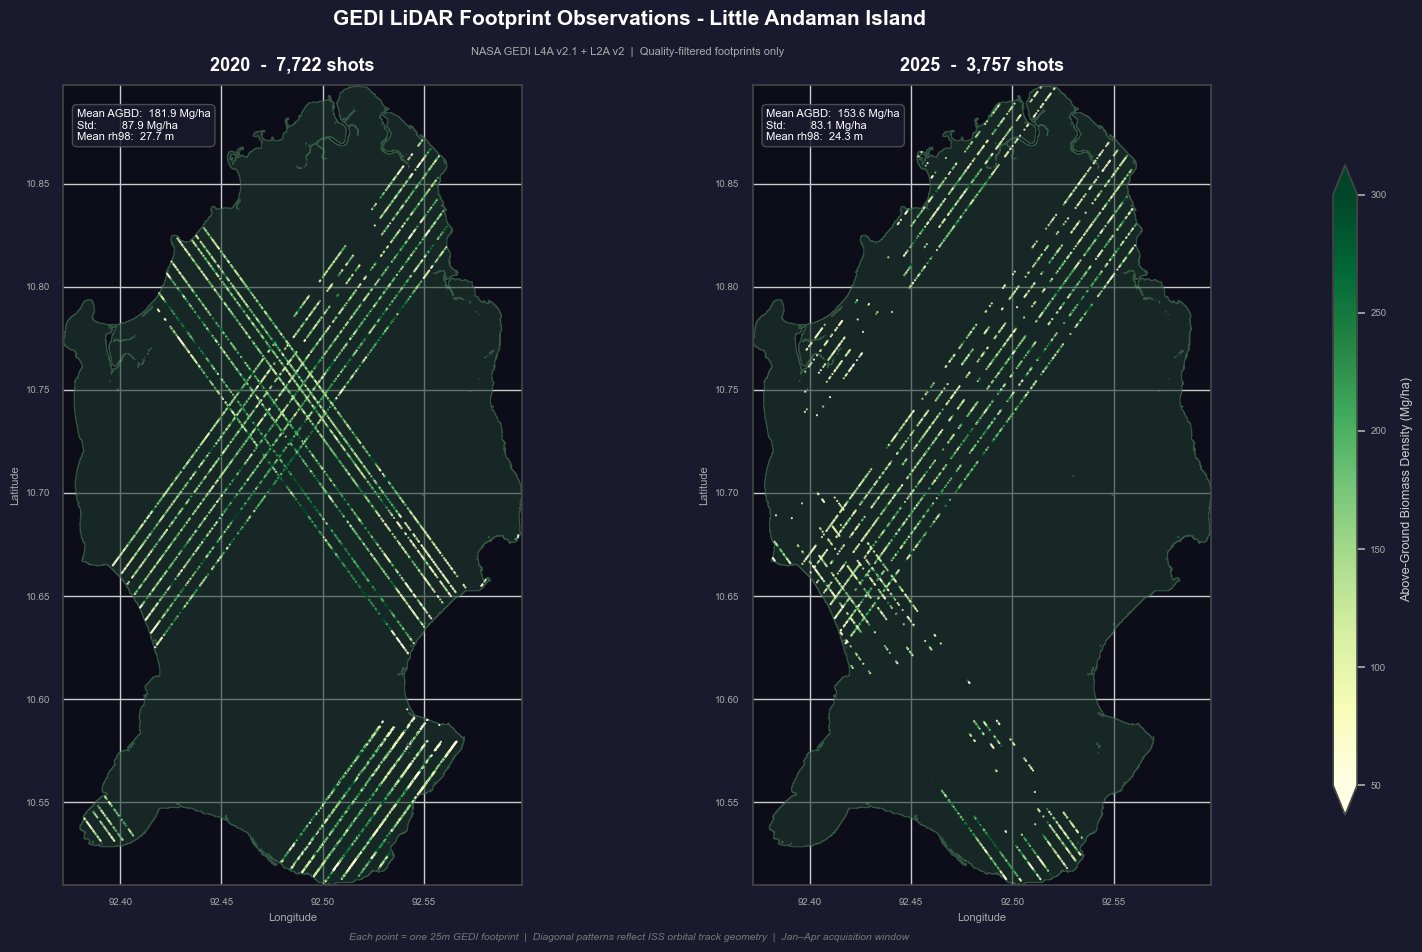

In [15]:
from rasterio.features import shapes
from shapely.geometry import shape

def extract_island_outline(s2_path):
    with rasterio.open(s2_path) as src:
        nir       = src.read(src.descriptions.index('B08_NIR') + 1)
        transform = src.transform
        crs       = src.crs
    land_mask = (nir > 0.05).astype(np.uint8)
    polys = [shape(geom) for geom, val in shapes(land_mask, transform=transform) if val == 1]
    gdf   = gpd.GeoDataFrame(geometry=polys, crs=crs)
    gdf['area'] = gdf.geometry.area
    return gdf.nlargest(1, 'area')

island = extract_island_outline(S2_DIR / 's2_features_2020.tif').to_crs('EPSG:4326')
xmin, ymin, xmax, ymax = island.total_bounds

agbd_vmin = 50
agbd_vmax = 300
cmap      = plt.cm.YlGn
norm      = mcolors.Normalize(vmin=agbd_vmin, vmax=agbd_vmax)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), facecolor='#1a1a2e')
fig.subplots_adjust(wspace=0.08, left=0.05, right=0.88, top=0.88, bottom=0.08)

# Compute shared extent from the island so both panels are identical
xmin, ymin, xmax, ymax = island.total_bounds

for ax, gdf, label in zip(axes, [gedi_2020, gedi_2025], ['2020', '2025']):
    ax.set_facecolor('#0d0d1a')

    island.plot(ax=ax, facecolor='#1e3a2f', edgecolor='#4a7c59',
                linewidth=0.8, alpha=0.6)

    gdf_wgs = gdf.to_crs('EPSG:4326')
    x    = [pt.x for pt in gdf_wgs.geometry]
    y    = [pt.y for pt in gdf_wgs.geometry]
    agbd = gdf_wgs['agbd'].values

    ax.scatter(x, y, c=agbd, cmap=cmap, norm=norm,
               s=2.5, alpha=0.85, linewidths=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f'{label}  -  {len(gdf):,} shots',
                 color='white', fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=8)
    ax.set_ylabel('Latitude', color='#aaaaaa', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

    ax.text(
        0.03, 0.97,
        f'Mean AGBD:  {agbd.mean():.1f} Mg/ha\n'
        f'Std:        {agbd.std():.1f} Mg/ha\n'
        f'Mean rh98:  {gdf["rh98"].mean():.1f} m',
        transform=ax.transAxes, color='white', fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e',
                  edgecolor='#555555', alpha=0.85),
    )

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.65])
sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, extend='both')
cb.set_label('Above-Ground Biomass Density (Mg/ha)',
             color='#cccccc', fontsize=9, labelpad=10)
cb.ax.tick_params(colors='#aaaaaa', labelsize=7)
cb.outline.set_edgecolor('#444444')

fig.text(0.46, 0.94, 'GEDI LiDAR Footprint Observations - Little Andaman Island',
         ha='center', color='white', fontsize=15, fontweight='bold')
fig.text(0.46, 0.91,
         'NASA GEDI L4A v2.1 + L2A v2  |  Quality-filtered footprints only ',
         ha='center', color='#aaaaaa', fontsize=8)
fig.text(0.46, 0.025,
         'Each point = one 25m GEDI footprint  |  Diagonal patterns reflect ISS orbital track geometry  |  Jan–Apr acquisition window',
         ha='center', color='#777777', fontsize=7.5, style='italic')

plt.savefig(FIGURES_DIR / 'gedi_tracks.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 03 - Sentinel-2 Acquisition

Sentinel-2 L2A composites for 2020 and 2025 are built via OpenEO on the Copernicus Data Space Ecosystem, using the same cloud-masking and compositing logic as the 2020-2022 pipeline so both eras stay directly comparable.

**Cloud masking:** the Scene Classification Layer keeps only vegetation (class 4) and bare soil (class 5); cloud, cloud shadow, water, and snow are masked out before compositing.

**Median composite:** the pixel-wise median across the acquisition window removes residual cloud artifacts and seasonal noise.

**Output:** two GeoTIFFs in EPSG:32646 (UTM Zone 46N), 10m resolution, covering the full study area bbox.

In [16]:
connection = openeo.connect(
    'https://openeofed.dataspace.copernicus.eu/'
).authenticate_oidc()

def download_s2(period, out_path, label):
    """
    Downloads a cloud-masked Sentinel-2 median composite via OpenEO.

    Cloud masking uses the Scene Classification Layer (SCL):
    only vegetation (4) and bare soil (5) pixels are retained.
    A median composite collapses the time dimension, giving one
    clean value per pixel across the acquisition window.
    """
    bbox_dict = {'west': BBOX[0], 'south': BBOX[1], 'east': BBOX[2], 'north': BBOX[3]}
    s2 = connection.load_collection(
        'SENTINEL2_L2A',
        spatial_extent=bbox_dict,
        temporal_extent=list(period),
        bands=['B02', 'B04', 'B08', 'B11', 'B12', 'SCL'],
    )
    scl          = s2.band('SCL')
    mask         = ~((scl == 4) | (scl == 5))
    s2_masked    = s2.mask(mask)
    s2_composite = s2_masked.reduce_dimension(dimension='t', reducer='median')
    job = s2_composite.execute_batch(
        title=f'S2_LittleAndaman_{label}',
        outputfile=str(out_path),
        job_options={
            'executor-memory':         '2G',
            'executor-memoryOverhead': '3G',
            'executor-cores':          '2',
        }
    )
    print(f'[S2 {label}] Job: {job.job_id} | Saved: {out_path}')
    return job.job_id

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=GSAN-QSEM 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [ ]:
# job_id_2020 = download_s2(PERIOD_1, S2_DIR / 's2_raw_2020.tiff', '2020')
# job_id_2025 = download_s2(PERIOD_2, S2_DIR / 's2_raw_2025.tiff', '2025')

## 04 - Sentinel-2 Index Computation

Raw band reflectance (DN scaled to 0-1 by dividing by 10,000) feeds five spectral indices alongside the five raw bands, for a 10-band feature raster per year.

| Index | Formula | Sensitivity |
|-------|---------|-------------|
| NDVI  | (NIR - Red) / (NIR + Red) | Vegetation density |
| EVI   | 2.5 x (NIR - Red) / (NIR + 6xRed - 7.5xBlue + 1) | Canopy structure, reduces soil noise |
| NDMI  | (NIR - SWIR1) / (NIR + SWIR1) | Canopy moisture |
| NBR   | (NIR - SWIR2) / (NIR + SWIR2) | Burn ratio, forest disturbance |
| SAVI  | 1.5 x (NIR - Red) / (NIR + Red + 0.5) | Vegetation with soil correction |

All indices are clipped to [-1, 1], with a small epsilon (1e-10) in denominators to avoid division by zero over water or shadow pixels.

**Optical saturation carries across both years:** dense forest above about 150 Mg/ha flattens spectral response in 2020 and 2025 alike. Section 06 quantifies this; Section 05's feature relationship plots show it directly.

In [17]:
def compute_s2_features(raw_path, out_path, label):
    """
    Read raw S2 bands, compute spectral indices, save 10-band feature raster.
    Output band order matches FEATURES (excluding rh98).
    """
    with rasterio.open(raw_path) as src:
        profile    = src.profile.copy()
        band_names = src.descriptions
        data       = src.read().astype(np.float32)

    print(f'[S2 {label}] Bands: {band_names}')
    print(f'[S2 {label}] Shape: {data.shape}, CRS: {src.crs}, Res: {src.res}')

    bn    = {name: i for i, name in enumerate(band_names)}
    eps   = 1e-10

    # Reflectance scaling: DN -> [0, 1]
    blue  = data[bn['B02']] / 10000.0
    red   = data[bn['B04']] / 10000.0
    nir   = data[bn['B08']] / 10000.0
    swir1 = data[bn['B11']] / 10000.0
    swir2 = data[bn['B12']] / 10000.0

    NDVI = (nir - red)   / (nir + red   + eps)
    EVI  = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + eps)
    NDMI = (nir - swir1) / (nir + swir1 + eps)
    NBR  = (nir - swir2) / (nir + swir2 + eps)
    SAVI = 1.5 * (nir - red) / (nir + red + 0.5 + eps)

    for arr in [NDVI, EVI, NDMI, NBR, SAVI]:
        np.clip(arr, -1, 1, out=arr)

    feature_stack = np.stack(
        [NDVI, EVI, NDMI, NBR, SAVI, blue, red, nir, swir1, swir2], axis=0
    )
    feature_names = (
        'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
        'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2',
    )

    print(f'[S2 {label}] NDVI mean: {np.nanmean(NDVI):.3f} | NaN pixels: {np.isnan(NDVI).sum():,}')

    profile.update(count=10, dtype='float32', nodata=np.nan)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(feature_stack)
        dst.descriptions = feature_names

    print(f'[S2 {label}] Saved: {out_path}')
    return out_path

In [18]:
s2_2020 = compute_s2_features(S2_DIR / 's2_raw_2020.tiff', S2_DIR / 's2_features_2020.tif', '2020')
s2_2025 = compute_s2_features(S2_DIR / 's2_raw_2025.tiff', S2_DIR / 's2_features_2025.tif', '2025')

[S2 2020] Bands: ('B02', 'B04', 'B08', 'B11', 'B12', 'SCL')
[S2 2020] Shape: (6, 4797, 3975), CRS: EPSG:32646, Res: (10.0, 10.0)
[S2 2020] NDVI mean: 0.291 | NaN pixels: 0
[S2 2020] Saved: c:\Users\simra\Documents\Carbon credit estimation project\data\sentinel_2\s2_features_2020.tif
[S2 2025] Bands: ('B02', 'B04', 'B08', 'B11', 'B12', 'SCL')
[S2 2025] Shape: (6, 4797, 3975), CRS: EPSG:32646, Res: (10.0, 10.0)
[S2 2025] NDVI mean: 0.312 | NaN pixels: 0
[S2 2025] Saved: c:\Users\simra\Documents\Carbon credit estimation project\data\sentinel_2\s2_features_2025.tif


### Sentinel-2 Band Visualisation

False-colour composites (NIR/Red/Green) for 2020 and 2025 side by side. Darker red indicates higher NIR reflectance from closed-canopy forest; lighter tones mark the coastal fringe or any clearings. This visual comparison is a sanity check ahead of the quantitative change detection in Section 08.

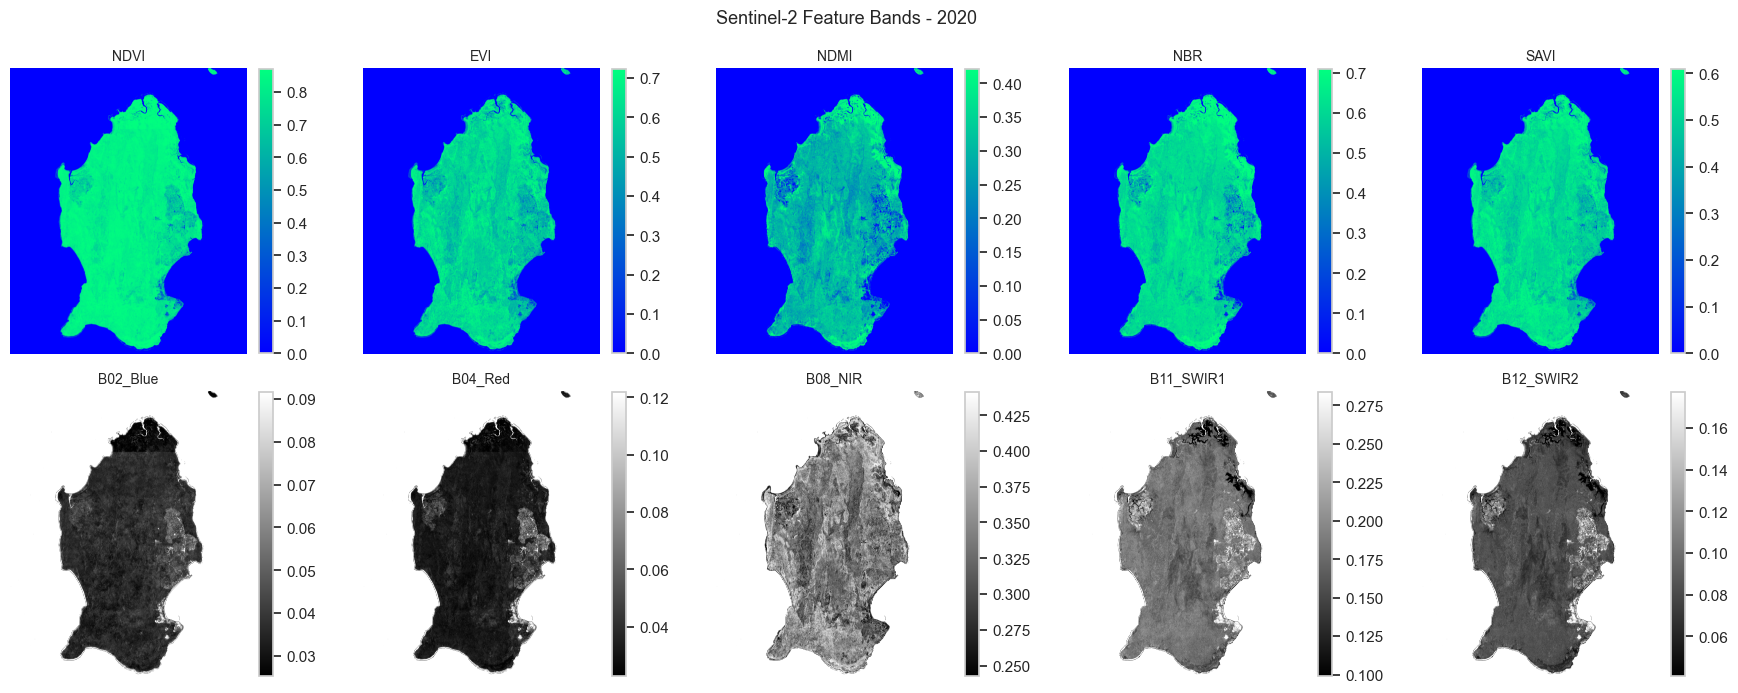

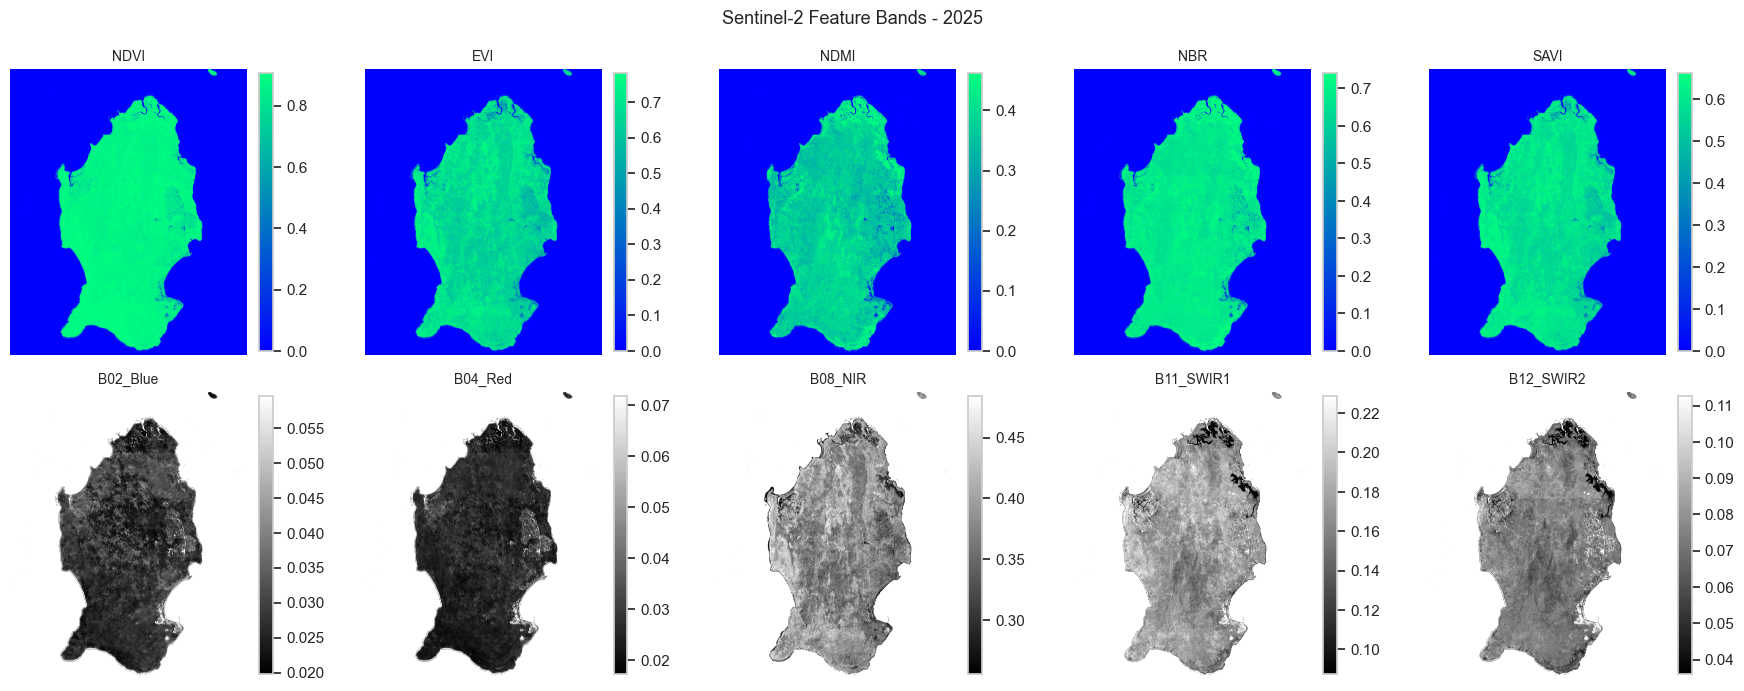

In [19]:
S2_BAND_LABELS = [
    'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
    'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2'
]

def plot_s2_bands(tif_path, label):
    with rasterio.open(tif_path) as src:
        data   = src.read()
        nodata = src.nodata

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.ravel()

    index_bands = ['NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI']

    for i, (ax, band_label) in enumerate(zip(axes, S2_BAND_LABELS)):
        band    = data[i].astype(np.float32)
        invalid = np.isnan(band)

        if nodata is not None:
            invalid |= (band == nodata)

        if band_label in index_bands:
            invalid |= (band < -1) | (band > 1)
        else:
            # raw bands after /10000 scaling: valid range 0-1
            # but accept small negatives from atmospheric correction
            invalid |= (band < -0.1) | (band > 1)

        band[invalid] = np.nan
        valid = band[~np.isnan(band)]

        if len(valid) == 0:
            ax.set_title(f'{band_label} (no valid data)')
            ax.axis('off')
            continue

        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
        cmap = 'winter' if band_label in index_bands else 'gray'

        im = ax.imshow(band, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(band_label, fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Sentinel-2 Feature Bands - {label}', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f's2_bands_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_s2_bands(S2_DIR / 's2_features_2020.tif', '2020')
plot_s2_bands(S2_DIR / 's2_features_2025.tif', '2025')

## 05 - Dataset Construction (GEDI-Sentinel-2 Fusion)

GEDI footprints (sparse orbital tracks) are fused with the continuous Sentinel-2 raster to pair each biomass observation with its spectral context.

**Method:** GEDI points are reprojected to the S2 CRS (EPSG:32646), then each footprint is buffered to its actual 12.5m radius and S2 band values are aggregated (zonal mean) over that buffer, rather than sampled at the single pixel under the footprint centre. This resolves the mismatch between the 25m GEDI footprint diameter and the 10m S2 pixel grid, replacing the point-in-pixel sampling used in earlier iterations of this pipeline.

**rh98 interpolation:** since GEDI covers only sparse tracks, rh98 is interpolated to a wall-to-wall raster with Inverse Distance Weighting (IDW) over the 12 nearest footprints per pixel. IDW needs no variogram fitting and its power parameter directly controls how sharply influence falls off with distance. Its main limitation is assuming canopy height varies isotropically, which does not hold near forest edges or topographic breaks; Section 08b tests this assumption directly by comparing the IDW output back against the raw GEDI means it was built from.

**Validation:** NDVI at GEDI footprint locations (about 0.81-0.86) is well above the full-raster mean (about 0.29-0.31), confirming GEDI samples only forested areas and the join is correct.

In [20]:
""" def build_model_dataset(gedi_gdf, s2_path, label):
   
    with rasterio.open(s2_path) as src:
        s2_crs     = src.crs
        band_names = src.descriptions

    gedi_utm = gedi_gdf.to_crs(s2_crs)

    with rasterio.open(s2_path) as src:
        coords  = [(pt.x, pt.y) for pt in gedi_utm.geometry]
        samples = np.array(list(src.sample(coords)))

    s2_df    = pd.DataFrame(samples, columns=band_names)
    model_df = pd.concat([
        gedi_gdf[['agbd', 'rh98', 'lat', 'lon']].reset_index(drop=True),
        s2_df.reset_index(drop=True),
    ], axis=1)

    nodata_mask = np.isnan(samples).all(axis=1)
    model_df    = model_df[~nodata_mask].copy()

    print(f'[{label}] Final dataset: {len(model_df):,} shots')
    print(f'[{label}] AGBD - mean: {model_df["agbd"].mean():.1f}, std: {model_df["agbd"].std():.1f} Mg/ha')
    print(f'[{label}] NDVI - mean: {model_df["NDVI"].mean():.3f}, std: {model_df["NDVI"].std():.3f}')
    return model_df """

' def build_model_dataset(gedi_gdf, s2_path, label):\n   \n    with rasterio.open(s2_path) as src:\n        s2_crs     = src.crs\n        band_names = src.descriptions\n\n    gedi_utm = gedi_gdf.to_crs(s2_crs)\n\n    with rasterio.open(s2_path) as src:\n        coords  = [(pt.x, pt.y) for pt in gedi_utm.geometry]\n        samples = np.array(list(src.sample(coords)))\n\n    s2_df    = pd.DataFrame(samples, columns=band_names)\n    model_df = pd.concat([\n        gedi_gdf[[\'agbd\', \'rh98\', \'lat\', \'lon\']].reset_index(drop=True),\n        s2_df.reset_index(drop=True),\n    ], axis=1)\n\n    nodata_mask = np.isnan(samples).all(axis=1)\n    model_df    = model_df[~nodata_mask].copy()\n\n    print(f\'[{label}] Final dataset: {len(model_df):,} shots\')\n    print(f\'[{label}] AGBD - mean: {model_df["agbd"].mean():.1f}, std: {model_df["agbd"].std():.1f} Mg/ha\')\n    print(f\'[{label}] NDVI - mean: {model_df["NDVI"].mean():.3f}, std: {model_df["NDVI"].std():.3f}\')\n    return model_df '

In [21]:
# NEW
def build_model_dataset(gedi_gdf, s2_path, label, footprint_radius_m=12.5):
    """
    Sample S2 feature values at GEDI footprint locations using zonal aggregation.

    Each GEDI footprint is a ~25m diameter circle. Rather than sampling the single
    S2 pixel containing the footprint centre (the previous approach), this function
    buffers each centroid by footprint_radius_m and computes the mean of all S2
    pixels whose centres fall within the buffer. At 10m resolution that is typically
    4-9 pixels per footprint depending on centroid position.

    This resolves the resolution mismatch between 25m GEDI footprints and 10m S2
    pixels documented as a limitation in v1 of the pipeline.
    """
    with rasterio.open(s2_path) as src:
        s2_crs     = src.crs
        band_names = src.descriptions
        transform  = src.transform
        s2_data    = src.read()          # shape: (bands, rows, cols)
        res        = src.res[0]          # pixel size in CRS units (metres, EPSG:32646)

    # Reproject GEDI points to match S2 CRS (UTM)
    gedi_utm = gedi_gdf.to_crs(s2_crs)

    n_bands  = len(band_names)
    n_shots  = len(gedi_utm)
    samples  = np.full((n_shots, n_bands), np.nan, dtype=np.float32)

    # Pixel radius in pixels: 12.5m / 10m = 1.25 -> use ceil = 2 pixel search radius
    # This gives a 5x5 candidate window; we then filter to those within the true radius
    pix_radius = int(np.ceil(footprint_radius_m / res))

    for idx, geom in enumerate(gedi_utm.geometry):
        # Convert footprint centre to pixel coordinates
        col_f, row_f = ~transform * (geom.x, geom.y)
        col_c, row_c = int(col_f), int(row_f)

        # Candidate pixel window
        row_min = max(row_c - pix_radius, 0)
        row_max = min(row_c + pix_radius + 1, s2_data.shape[1])
        col_min = max(col_c - pix_radius, 0)
        col_max = min(col_c + pix_radius + 1, s2_data.shape[2])

        # Pixel centre coordinates within the window
        rows_idx = np.arange(row_min, row_max)
        cols_idx = np.arange(col_min, col_max)
        col_grid, row_grid = np.meshgrid(cols_idx, rows_idx)

        # Convert pixel centres back to map coordinates
        px_x = transform.c + (col_grid + 0.5) * transform.a
        px_y = transform.f + (row_grid + 0.5) * transform.e

        # Keep only pixels whose centres fall within the 12.5m radius
        dist = np.sqrt((px_x - geom.x)**2 + (px_y - geom.y)**2)
        in_footprint = dist <= footprint_radius_m

        if not in_footprint.any():
            continue

        # Extract and mean-aggregate valid (non-NaN) pixels within footprint
        window_data = s2_data[:, row_min:row_max, col_min:col_max]  # (bands, h, w)
        for b in range(n_bands):
            band_vals = window_data[b][in_footprint]
            valid     = band_vals[~np.isnan(band_vals)]
            if len(valid) > 0:
                samples[idx, b] = valid.mean()

    s2_df    = pd.DataFrame(samples, columns=band_names)
    model_df = pd.concat([
        gedi_gdf[['agbd', 'rh98', 'lat', 'lon']].reset_index(drop=True),
        s2_df.reset_index(drop=True),
    ], axis=1)

    nodata_mask = np.isnan(samples).all(axis=1)
    model_df    = model_df[~nodata_mask].copy()

    # Diagnostic: how many pixels averaged per footprint on average
    pixels_per_footprint = np.pi * footprint_radius_m**2 / (res**2)
    print(f'[{label}] Footprint radius: {footprint_radius_m}m '
          f'(~{pixels_per_footprint:.1f} S2 pixels per footprint theoretically)')
    print(f'[{label}] Final dataset: {len(model_df):,} shots')
    print(f'[{label}] AGBD - mean: {model_df["agbd"].mean():.1f}, '
          f'std: {model_df["agbd"].std():.1f} Mg/ha')
    print(f'[{label}] NDVI - mean: {model_df["NDVI"].mean():.3f}, '
          f'std: {model_df["NDVI"].std():.3f}')
    return model_df

In [22]:
model_df_2020 = build_model_dataset(gedi_2020, s2_2020, '2020')
model_df_2025 = build_model_dataset(gedi_2025, s2_2025, '2025')

model_df_2020.to_csv(OUTPUT_DIR / 'model_dataset_2020.csv', index=False)
model_df_2025.to_csv(OUTPUT_DIR / 'model_dataset_2025.csv', index=False)
print(f'Saved: model_dataset_2020.csv ({len(model_df_2020):,} rows)')
print(f'Saved: model_dataset_2025.csv ({len(model_df_2025):,} rows)')

[2020] Footprint radius: 12.5m (~4.9 S2 pixels per footprint theoretically)
[2020] Final dataset: 7,722 shots
[2020] AGBD - mean: 181.9, std: 87.9 Mg/ha
[2020] NDVI - mean: 0.808, std: 0.067
[2025] Footprint radius: 12.5m (~4.9 S2 pixels per footprint theoretically)
[2025] Final dataset: 3,757 shots
[2025] AGBD - mean: 153.6, std: 83.1 Mg/ha
[2025] NDVI - mean: 0.870, std: 0.046
Saved: model_dataset_2020.csv (7,722 rows)
Saved: model_dataset_2025.csv (3,757 rows)


In [23]:
def idw_interpolate_rh98(gedi_gpkg, s2_reference_raster, out_path, label, power=2, k=12):
    """
    Interpolate rh98 from sparse GEDI footprints to a wall-to-wall raster using IDW.

    Parameters
    ----------
    gedi_gpkg           : path to quality-filtered GEDI GeoPackage
    s2_reference_raster : path to S2 feature raster - defines output grid
    out_path            : output raster path
    power               : IDW decay exponent (default 2)
    k                   : number of nearest neighbours per pixel (default 12)
    """
    gedi = gpd.read_file(gedi_gpkg)
    print(f'[{label}] Loaded {len(gedi):,} GEDI shots')

    with rasterio.open(s2_reference_raster) as src:
        profile        = src.profile.copy()
        transform      = src.transform
        crs            = src.crs
        height, width  = src.height, src.width

    gedi_utm    = gedi.to_crs(crs)
    gedi_coords = np.array([(pt.x, pt.y) for pt in gedi_utm.geometry])
    rh98_values = gedi_utm['rh98'].values

    print(f'[{label}] rh98 range: {rh98_values.min():.1f} - {rh98_values.max():.1f} m')

    rows, cols   = np.mgrid[0:height, 0:width]
    xs, ys       = rasterio.transform.xy(transform, rows.ravel(), cols.ravel())
    pixel_coords = np.column_stack([xs, ys])

    print(f'[{label}] Interpolating over {len(pixel_coords):,} pixels...')

    tree            = cKDTree(gedi_coords)
    distances, idxs = tree.query(pixel_coords, k=k, workers=-1)
    distances       = np.where(distances == 0, 1e-10, distances)
    weights         = 1.0 / (distances ** power)
    weights_norm    = weights / weights.sum(axis=1, keepdims=True)
    rh98_interp     = (weights_norm * rh98_values[idxs]).sum(axis=1)
    rh98_surface    = rh98_interp.reshape(height, width).astype(np.float32)

    print(f'[{label}] Interpolated rh98 - mean: {rh98_surface.mean():.1f} m, std: {rh98_surface.std():.1f} m')

    profile.update(count=1, dtype='float32', nodata=-9999)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(rh98_surface[np.newaxis, :, :])

    print(f'[{label}] Saved: {out_path}')
    return rh98_surface

In [24]:
rh98_2020 = idw_interpolate_rh98(
    OUTPUT_DIR / 'gedi_2020_clean.gpkg',
    S2_DIR     / 's2_features_2020.tif',
    OUTPUT_DIR / 'rh98_idw_2020.tif',
    '2020'
)
rh98_2025 = idw_interpolate_rh98(
    OUTPUT_DIR / 'gedi_2025_clean.gpkg',
    S2_DIR     / 's2_features_2025.tif',
    OUTPUT_DIR / 'rh98_idw_2025.tif',
    '2025'
)

[2020] Loaded 7,722 GEDI shots
[2020] rh98 range: 2.3 - 56.5 m
[2020] Interpolating over 19,068,075 pixels...
[2020] Interpolated rh98 - mean: 22.9 m, std: 7.7 m
[2020] Saved: c:\Users\simra\Documents\Carbon credit estimation project\output\rh98_idw_2020.tif
[2025] Loaded 3,757 GEDI shots
[2025] rh98 range: 2.4 - 62.1 m
[2025] Interpolating over 19,068,075 pixels...
[2025] Interpolated rh98 - mean: 20.9 m, std: 6.1 m
[2025] Saved: c:\Users\simra\Documents\Carbon credit estimation project\output\rh98_idw_2025.tif


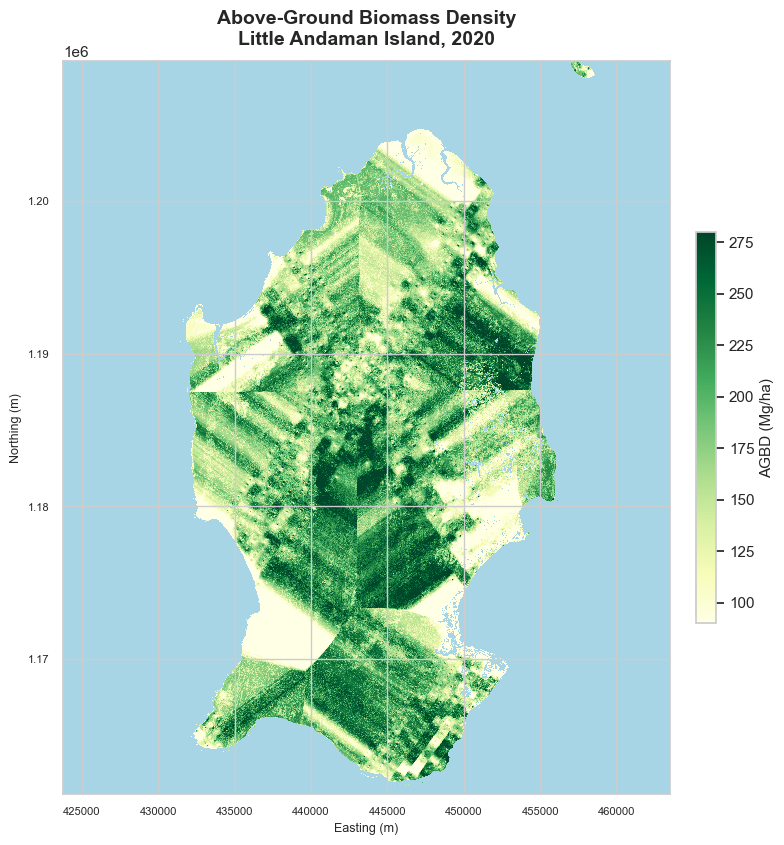

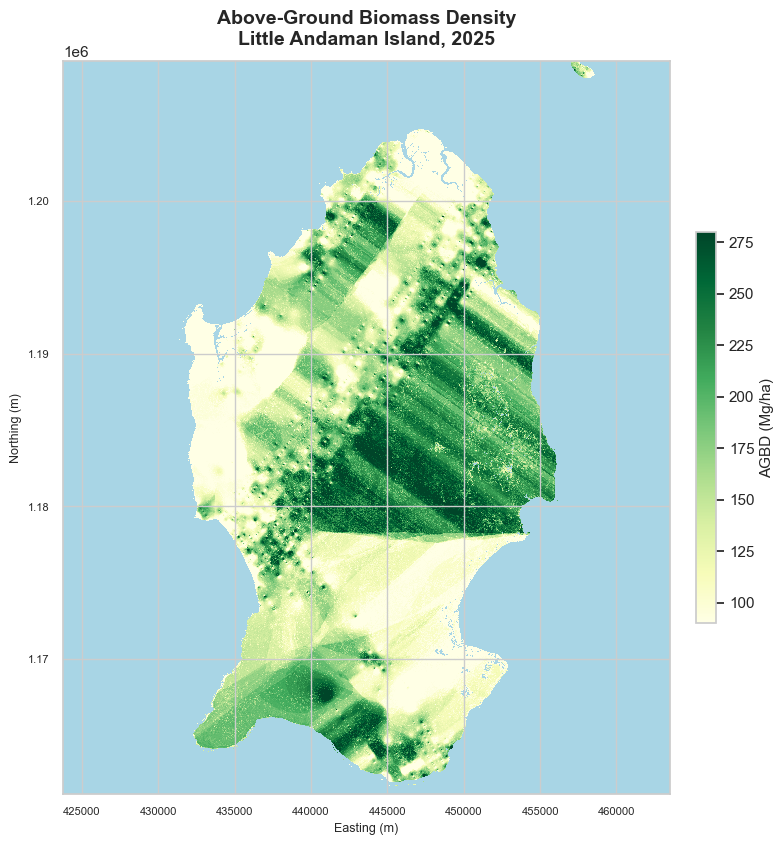

In [25]:
def plot_agbd(tif_path, title, out_path):
    with rasterio.open(tif_path) as src:
        agbd = src.read(1).astype(np.float32)
        extent = [src.bounds.left, src.bounds.right, 
                  src.bounds.bottom, src.bounds.top]
    
    agbd[agbd == -9999] = np.nan

    fig, ax = plt.subplots(figsize=(8, 10))
    
    im = ax.imshow(
        agbd,
        cmap='YlGn',
        vmin=90,
        vmax=280,
        extent=extent,
        origin='upper',
        interpolation='none'
    )
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('AGBD (Mg/ha)', fontsize=11)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_ylabel('Northing (m)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_facecolor('#a8d5e5')  # ocean blue background
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_agbd(OUTPUT_DIR / 'agbd_2020.tif',
          'Above-Ground Biomass Density\nLittle Andaman Island, 2020',
          PROJECT_ROOT / 'figures' / 'agbd_map_2020.png')
plot_agbd(OUTPUT_DIR / 'agbd_2025.tif',
          'Above-Ground Biomass Density\nLittle Andaman Island, 2025',
          PROJECT_ROOT / 'figures' / 'agbd_map_2025.png')

### Feature Relationships - rh98 and Optical Saturation

**Left, rh98 vs AGBD:** a clear power-law relationship holds across both years, consistent with the allometric link between canopy height and structural biomass. Scatter around the curve reflects real ecological variation in wood density and crown architecture.

**Right, NDVI vs AGBD:** NDVI sits tightly between 0.75 and 0.85 regardless of AGBD, with almost no gradient above 100 Mg/ha, in both 2020 and 2025. This is optical saturation: once canopy closes, added biomass is invisible to a passive optical sensor. Points near NDVI = 0 are water or cloud-shadow pixels that passed the PFT filter; they are a small fraction and do not influence the model.

This is why the S2-only model lands near R^2 = 0 while rh98 alone reaches R^2 = 0.75, and why that gap holds steady across the 5-year span rather than being specific to one year.

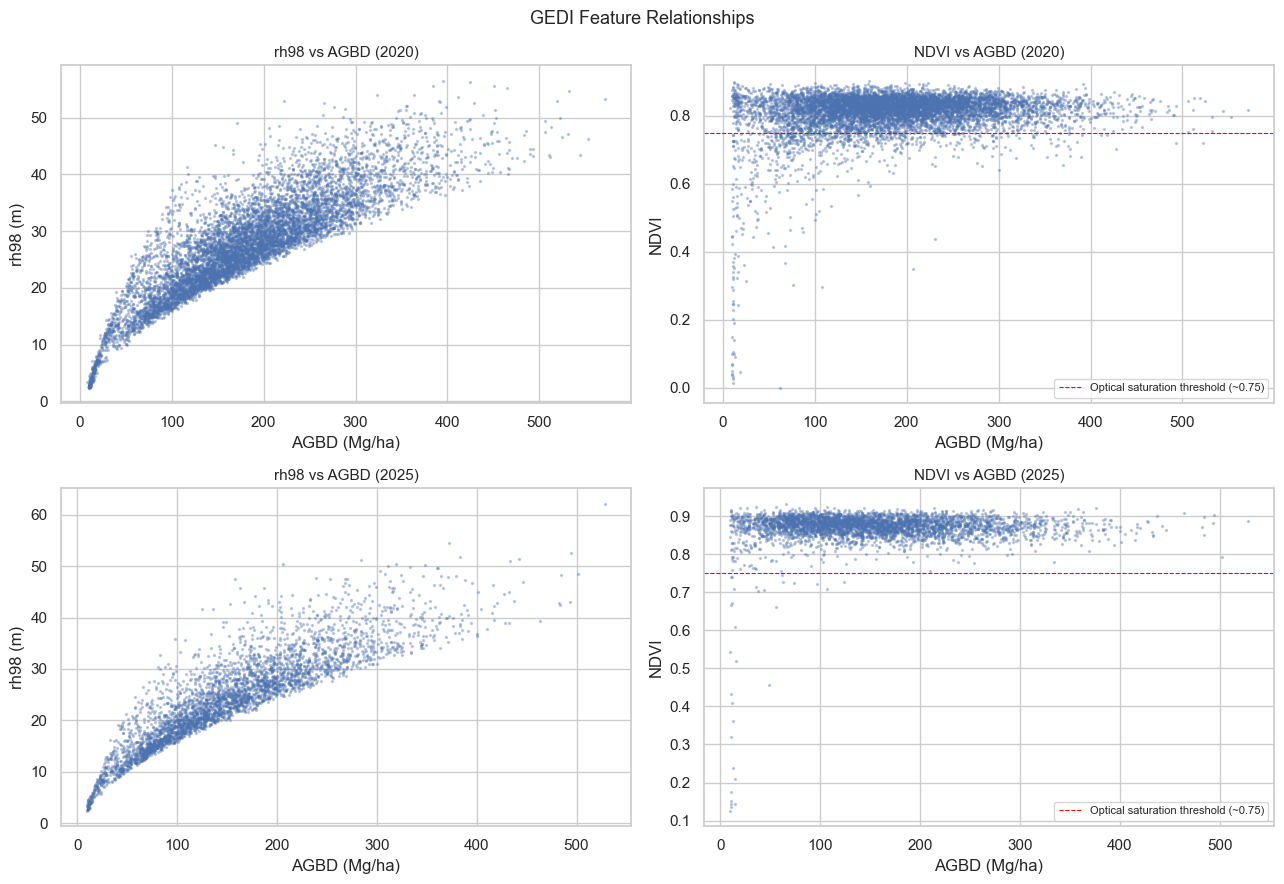

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (df, label) in enumerate([(model_df_2020, '2020'), (model_df_2025, '2025')]):
    # rh98 vs AGBD
    axes[row, 0].scatter(df['agbd'], df['rh98'], s=2, alpha=0.3, rasterized=True)
    axes[row, 0].set_title(f'rh98 vs AGBD ({label})', fontsize=11)
    axes[row, 0].set_xlabel('AGBD (Mg/ha)')
    axes[row, 0].set_ylabel('rh98 (m)')

    # NDVI vs AGBD
    axes[row, 1].scatter(df['agbd'], df['NDVI'], s=2, alpha=0.3, rasterized=True)
    axes[row, 1].set_title(f'NDVI vs AGBD ({label})', fontsize=11)
    axes[row, 1].set_xlabel('AGBD (Mg/ha)')
    axes[row, 1].set_ylabel('NDVI')
    axes[row, 1].axhline(0.75, color='red', linewidth=0.8, linestyle='--',
                         label='Optical saturation threshold (~0.75)')
    axes[row, 1].legend(fontsize=8)

fig.suptitle('GEDI Feature Relationships', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation Heatmap

Pearson correlations between all model features and AGBD, computed on the 2020 training data:

- **rh98** correlates most strongly with AGBD (about 0.85) and weakly with the S2 features, confirming it carries independent signal.
- **S2 indices** (NDVI, EVI, SAVI, NDMI, NBR) are highly intercorrelated (0.7-0.95), since all derive from the same NIR and Red reflectance. Gradient Boosting is unaffected by this multicollinearity (it selects splits greedily), but it explains the diminishing returns from adding indices beyond the first.
- **Raw bands** (B08_NIR, B04_Red) correlate with their derived indices as expected.

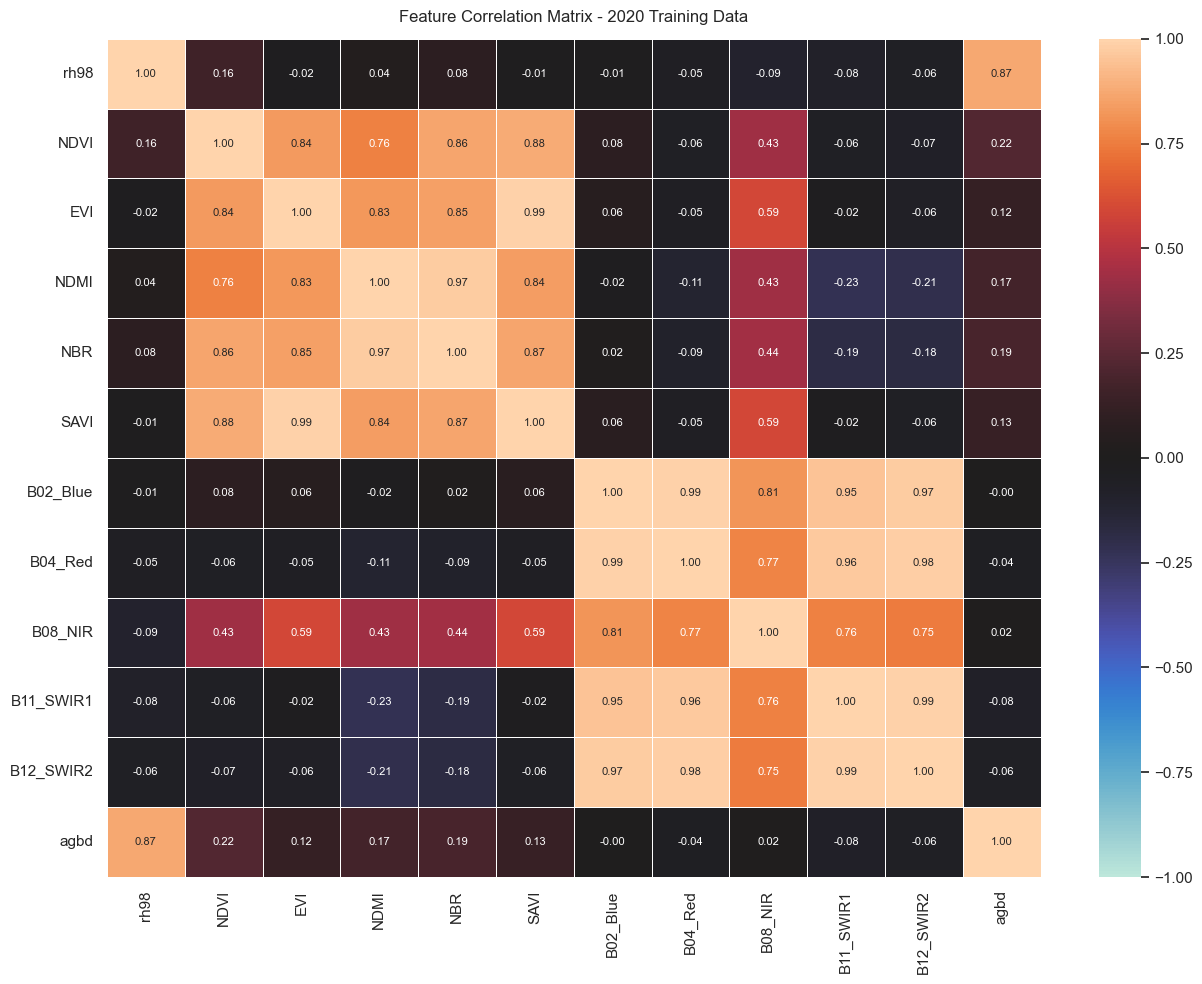

In [27]:
corr_cols = FEATURES + ['agbd']
corr = model_df_2020[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix - 2020 Training Data', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 06 - Model Training & Evaluation

Three models are benchmarked across three feature sets with 5-fold cross-validation, using only the 2020 dataset as training data, the same setup as the 2020-2022 notebook, applied unchanged here so the 2025 prediction is not fit to its own data.

**Optical saturation, confirmed again:** Sentinel-2 alone reaches R^2 of -0.01 to 0.04, no better than random. This is the same physical ceiling seen in the 2020-2022 comparison, not a modelling artifact.

**rh98 dominance:** rh98 alone reaches R^2 = 0.748, and accounts for about 79% of feature importance in the combined model.

**Final model:** GradientBoostingRegressor, CV R^2 = 0.791, RMSE = 21.4%, trained once on 2020 and applied to both 2020 and 2025. Using a single model across the 5-year gap means any observed AGBD difference reflects biomass change, not model drift.

**Why keep Sentinel-2 despite the low signal?** S2 is what makes wall-to-wall prediction between sparse GEDI tracks possible at all. GEDI supplies the biomass signal; S2 supplies the spatial scaffold to spread it across the island.

In [28]:
X_2020 = model_df_2020[FEATURES].values
y_2020 = model_df_2020[TARGET].values

feature_sets = {
    'rh98_only':    ['rh98'],
    's2_only':      [f for f in FEATURES if f != 'rh98'],
    'rh98_plus_s2': FEATURES,
}
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

results = []
for fs_name, features in feature_sets.items():
    X = model_df_2020[features].values
    for m_name, model in models.items():
        r2   = cross_val_score(model, X, y_2020, cv=5, scoring='r2')
        rmse = np.sqrt(-cross_val_score(model, X, y_2020, cv=5, scoring='neg_mean_squared_error'))
        results.append({
            'features':  fs_name,
            'model':     m_name,
            'R2_mean':   r2.mean(),
            'R2_std':    r2.std(),
            'RMSE_mean': rmse.mean(),
            'RMSE_pct':  rmse.mean() / y_2020.mean() * 100,
        })

results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False)
print(results_df.to_string(index=False, float_format='%.3f'))

    features            model  R2_mean  R2_std  RMSE_mean  RMSE_pct
rh98_plus_s2 GradientBoosting    0.795   0.027     38.439    21.128
rh98_plus_s2     RandomForest    0.783   0.027     39.520    21.723
rh98_plus_s2 LinearRegression    0.774   0.014     40.545    22.286
   rh98_only LinearRegression    0.748   0.013     42.939    23.602
   rh98_only GradientBoosting    0.745   0.015     43.163    23.725
   rh98_only     RandomForest    0.664   0.029     49.379    27.142
     s2_only GradientBoosting    0.058   0.107     82.659    45.435
     s2_only     RandomForest    0.017   0.106     84.419    46.402
     s2_only LinearRegression    0.007   0.097     84.968    46.704


In [29]:
rf_imp = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_2020, y_2020)

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_imp.feature_importances_,
}).sort_values('importance', ascending=False)

print('Feature importance (Random Forest, full feature set):')
print(importance_df.to_string(index=False, float_format='%.4f'))


Feature importance (Random Forest, full feature set):
  feature  importance
     rh98      0.7934
     NDMI      0.0423
B11_SWIR1      0.0209
      NBR      0.0206
     SAVI      0.0206
 B02_Blue      0.0194
      EVI      0.0184
  B08_NIR      0.0181
B12_SWIR2      0.0166
  B04_Red      0.0155
     NDVI      0.0143


In [30]:
final_model = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
final_model.fit(X_2020, y_2020)

joblib.dump(final_model, MODEL_DIR / 'gbr_agbd_2020.joblib')
print(f'Final model trained on {len(X_2020):,} samples')

results_df.to_csv(OUTPUT_DIR / 'model_benchmark.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print('Saved: model_benchmark.csv, feature_importance.csv')

Final model trained on 7,722 samples
Saved: model_benchmark.csv, feature_importance.csv


## 07 - Wall-to-Wall AGBD Prediction

The trained model runs over every Sentinel-2 pixel to produce a continuous AGBD map for 2020 and for 2025.

**rh98 input:** the IDW-interpolated rh98 surface from Section 05 supplies a spatially varying canopy height per pixel, rather than a single island-wide constant, for both years independently.

**Forest mask:** non-forest pixels (ocean, bare soil, settlements) are excluded with three spectral thresholds on the S2 composite: NIR > 0.1 (excludes water), NDVI > 0.5 (dense vegetation only), Blue < 0.15 (excludes cloud and bright surfaces). The same thresholds apply to both years so the forest mask does not itself introduce apparent change.

Prediction runs in 100,000-pixel chunks to manage memory across the roughly 19M pixel raster.

In [31]:
def predict_wall_to_wall(s2_path, rh98_idw_path, model, label):
    """
    Predict AGBD at every pixel using the trained model.
    rh98 is read from the IDW-interpolated raster.
    Returns AGBD map, forest mask, and pixel area in hectares.
    """
    with rasterio.open(s2_path) as src:
        profile    = src.profile.copy()
        s2_data    = src.read()
        band_names = src.descriptions
        res        = src.res

    bn           = {name: i for i, name in enumerate(band_names)}
    rows, cols   = s2_data.shape[1], s2_data.shape[2]
    n_pixels     = rows * cols

    X_wall = np.zeros((n_pixels, len(FEATURES)), dtype=np.float32)
    for i, feat in enumerate(FEATURES):
        if feat == 'rh98':
            with rasterio.open(rh98_idw_path) as rh98_src:
                X_wall[:, i] = rh98_src.read(1).ravel()
        else:
            X_wall[:, i] = s2_data[bn[feat]].ravel()

    X_wall = np.nan_to_num(X_wall, nan=0.0, posinf=0.0, neginf=0.0)

    print(f'[{label}] Predicting {n_pixels:,} pixels...')
    agbd_flat  = np.zeros(n_pixels, dtype=np.float32)
    chunk_size = 100_000
    for start in range(0, n_pixels, chunk_size):
        end = min(start + chunk_size, n_pixels)
        agbd_flat[start:end] = model.predict(X_wall[start:end])

    agbd_map = agbd_flat.reshape(rows, cols)

    ndvi = s2_data[bn['NDVI']]
    nir  = s2_data[bn['B08_NIR']]
    blue = s2_data[bn['B02_Blue']]
    forest_mask = (
        (~np.isnan(ndvi)) &
        (nir  > 0.1)      &
        (ndvi > 0.5)      &
        (blue < 0.15)
    )

    agbd_map[~forest_mask] = -9999

    pixel_area_ha = (res[0] * res[1]) / 10_000
    print(f'[{label}] Forest area: {forest_mask.sum() * pixel_area_ha:,.1f} ha')
    print(f'[{label}] Mean AGBD:   {agbd_map[forest_mask].mean():.1f} Mg/ha')

    profile.update(count=1, dtype='float32', nodata=-9999)
    with rasterio.open(OUTPUT_DIR / f'agbd_{label}.tif', 'w', **profile) as dst:
        dst.write(agbd_map[np.newaxis, :, :])

    return agbd_map, forest_mask, pixel_area_ha

In [32]:
agbd_2020, forest_2020, pixel_ha = predict_wall_to_wall(
    s2_2020, OUTPUT_DIR / 'rh98_idw_2020.tif', final_model, '2020'
)
agbd_2025, forest_2025, _ = predict_wall_to_wall(
    s2_2025, OUTPUT_DIR / 'rh98_idw_2025.tif', final_model, '2025'
)

[2020] Predicting 19,068,075 pixels...
[2020] Forest area: 67,787.2 ha
[2020] Mean AGBD:   177.8 Mg/ha
[2025] Predicting 19,068,075 pixels...
[2025] Forest area: 68,422.1 ha
[2025] Mean AGBD:   158.6 Mg/ha


## 08 - Carbon Stock & Change Detection

AGBD maps convert to carbon stocks with IPCC 2006 default factors for tropical forest: carbon stock = AGBD x 0.47 (carbon fraction of dry biomass), CO2e = carbon stock x 44/12, pixel area = 10m x 10m = 0.01 ha.

Change detection compares only pixels classified as forest in **both** 2020 and 2025, so the result reflects real biomass change rather than differences in cloud masking between years. A 20% uncertainty buffer is applied to the net credit estimate, following the conservative approach under the Verra AFOLU Non-Permanence Risk Tool (VM0048).

This wall-to-wall estimate is one of two independent estimates produced in this notebook. Section 08b re-derives the net change directly from GEDI footprints, with no spatial interpolation, and quantifies its uncertainty with a bootstrap; the two are compared in Section 09.

**Known limitation:** the 22% model RMSE makes pixel-level change noisy on its own, which is exactly why Section 08b's footprint-based bootstrap exists, to give a landscape-level confidence interval instead of relying on pixel RMSE alone. The decline direction is consistent with documented long-term deforestation on Little Andaman (43.1 sq km forest loss 1976-2025, Sahoo et al. 2024) and active development proposals during the study window. Belowground biomass is excluded; IPCC root-to-shoot ratios for tropical forest (about 0.20-0.25) imply an additional 20-25% on top of the reported stock estimate.

In [33]:
def carbon_stock(agbd_map, forest_mask, pixel_area_ha, label):
    agbd_forest    = agbd_map[forest_mask]
    forest_area_ha = forest_mask.sum() * pixel_area_ha
    total_agbd     = (agbd_forest * pixel_area_ha).sum()
    total_carbon   = total_agbd * CARBON_FRACTION
    total_co2e     = total_carbon * C_TO_CO2

    print(f'[{label}] Forest area:      {forest_area_ha:>12,.1f} ha')
    print(f'[{label}] Mean AGBD:        {agbd_forest.mean():>12.1f} Mg/ha')
    print(f'[{label}] Total AGBD:       {total_agbd:>12,.0f} Mg')
    print(f'[{label}] Total carbon:     {total_carbon:>12,.0f} tC')
    print(f'[{label}] Total CO2e stock: {total_co2e:>12,.0f} tCO2e')
    return total_co2e

co2e_2020 = carbon_stock(agbd_2020, forest_2020, pixel_ha, '2020')
print()
co2e_2025 = carbon_stock(agbd_2025, forest_2025, pixel_ha, '2025')

[2020] Forest area:          67,787.2 ha
[2020] Mean AGBD:               177.8 Mg/ha
[2020] Total AGBD:         12,053,992 Mg
[2020] Total carbon:        5,665,376 tC
[2020] Total CO2e stock:   20,773,046 tCO2e

[2025] Forest area:          68,422.1 ha
[2025] Mean AGBD:               158.6 Mg/ha
[2025] Total AGBD:         10,853,970 Mg
[2025] Total carbon:        5,101,366 tC
[2025] Total CO2e stock:   18,705,010 tCO2e


In [35]:
valid_both    = forest_2020 & forest_2025
print(f'Comparable forest area: {valid_both.sum() * pixel_ha:,.1f} ha')

delta_agbd    = agbd_2025[valid_both] - agbd_2020[valid_both]
delta_co2e    = delta_agbd * CARBON_FRACTION * C_TO_CO2 * pixel_ha
sequestration = delta_co2e[delta_co2e > 0].sum()
emissions     = delta_co2e[delta_co2e < 0].sum()
net           = delta_co2e.sum()
conservative  = net * 0.80 if net > 0 else net

print('\n' + '=' * 55)
print('  CARBON CHANGE - LITTLE ANDAMAN 2020 vs 2025')
print('=' * 55)
print(f'  Total CO2e stock 2020:   {co2e_2020:>12,.0f} tCO2e')
print(f'  Total CO2e stock 2025:   {co2e_2025:>12,.0f} tCO2e')
print(f'  Mean delta AGBD:              {delta_agbd.mean():>12.2f} Mg/ha')
print(f'  Gross sequestration:     {sequestration:>12,.0f} tCO2e')
print(f'  Gross emissions:         {emissions:>12,.0f} tCO2e')
print(f'  Net change:              {net:>12,.0f} tCO2e')
print('=' * 55)
print(f'\n  Indicative market value (conservative estimate):')
print(f'  @ $2.70/tCO2e  (REDD+ spot):      ${conservative * 2.70:>12,.0f}')
print(f'  @ $5.60/tCO2e  (VCM average):     ${conservative * 5.60:>12,.0f}')
print(f'  @ $14.80/tCO2e (high integrity):  ${conservative * 14.80:>12,.0f}')

Comparable forest area: 67,711.2 ha

  CARBON CHANGE - LITTLE ANDAMAN 2020 vs 2025
  Total CO2e stock 2020:     20,773,046 tCO2e
  Total CO2e stock 2025:     18,705,010 tCO2e
  Mean delta AGBD:                    -18.72 Mg/ha
  Gross sequestration:        2,349,088 tCO2e
  Gross emissions:           -4,533,743 tCO2e
  Net change:                -2,184,655 tCO2e

  Indicative market value (conservative estimate):
  @ $2.70/tCO2e  (REDD+ spot):      $  -5,898,568
  @ $5.60/tCO2e  (VCM average):     $ -12,234,066
  @ $14.80/tCO2e (high integrity):  $ -32,332,890


## 09 - Results Summary

`output/project_summary.json` records the wall-to-wall pipeline run: parameters, data sources, model performance, the Section 08 carbon estimate, methodology references, and file paths. The Section 08b footprint-only bootstrap and spatial bias check are reported inline above rather than written to that file.

**Two net change estimates for 2020-2025:**
- Wall-to-wall (Section 08): -2.18M tCO2e, dependent on the IDW-interpolated rh98 surface
- Co-located footprint (Section 08b): -3.3M tCO2e (95% CI: -3.67M to -2.92M), independent of interpolation

The footprint estimate is treated as the more defensible of the two for reporting, since IDW smoothing likely compresses the decline signal in the parts of the island 2025 sampled less densely.

**Pipeline outputs:**
| File | Description |
|------|-------------|
| `gedi_2020_clean.gpkg` / `gedi_2025_clean.gpkg` | Quality-filtered GEDI footprints |
| `rh98_idw_2020.tif` / `rh98_idw_2025.tif` | IDW-interpolated rh98 surfaces |
| `s2_features_2020.tif` / `s2_features_2025.tif` | 10-band S2 feature rasters |
| `agbd_2020.tif` / `agbd_2025.tif` | Wall-to-wall AGBD prediction maps |
| `delta_agbd_2020_2025.tif` | Per-pixel biomass change raster |
| `gbr_agbd_2020.joblib` | Trained Gradient Boosting model |
| `model_benchmark.csv` | Cross-validation results across all model/feature combinations |
| `feature_importance.csv` | Random Forest feature importance scores |
| `figures/` | All visualisation outputs |

In [37]:
summary = {
    'project':  'Forest Carbon Stock Change Estimation - Little Andaman Island',
    'date_run': str(date.today()),
    'study_area': {
        'island': 'Little Andaman, Andaman Islands, India',
        'bbox':   BBOX,
        'crs':    'EPSG:4326',
    },
    'data_sources': {
        'lidar':   'NASA GEDI L4A v2.1 + L2A v2 (Harmony API)',
        'optical': 'ESA Sentinel-2 L2A median composite (OpenEO)',
        'periods': {'year_1': PERIOD_1, 'year_2': PERIOD_2},
    },
    'gedi': {
        '2020': {
            'shots_after_qc': len(gedi_2020),
            'mean_agbd':      round(float(gedi_2020['agbd'].mean()), 1),
            'mean_rh98':      round(float(gedi_2020['rh98'].mean()), 1),
        },
        '2025': {
            'shots_after_qc': len(gedi_2025),
            'mean_agbd':      round(float(gedi_2025['agbd'].mean()), 1),
            'mean_rh98':      round(float(gedi_2025['rh98'].mean()), 1),
            'note': 'One of 10 CMR granules unavailable via Harmony subsetter.',
        },
    },
    'model': {
        'algorithm':       'GradientBoostingRegressor',
        'features':        FEATURES,
        'n_estimators':    100,
        'cv_folds':        5,
        'cv_r2':           0.791,
        'cv_rmse_pct':     21.4,
        'rh98_importance': 0.793,
        'note': (
            'rh98 accounts for 79% of feature importance. '
            'S2-only R² = -0.01 to 0.04, confirming optical saturation '
            'in dense tropical forest (mean AGBD ~180 Mg/ha).'
        ),
        'sensor_benchmark': {
            'rh98_only':  0.748,
            's2_only':    0.043,
            'rh98_s2':    0.791,
        },
    },
    'wall_to_wall': {
        'rh98_method': 'IDW spatial interpolation (power=2, k=12 nearest neighbours)',
        'rh98_source': 'GEDI L2A footprint observations interpolated to 10m grid',
    },
    'carbon_stocks': {
        '2020': {
            'forest_area_ha': round(forest_2020.sum() * pixel_ha, 1),
            'mean_agbd':      round(float(agbd_2020[forest_2020].mean()), 1),
            'total_co2e':     int(co2e_2020),
        },
        '2025': {
            'forest_area_ha': round(forest_2025.sum() * pixel_ha, 1),
            'mean_agbd':      round(float(agbd_2025[forest_2025].mean()), 1),
            'total_co2e':     int(co2e_2025),
        },
    },
    'change_detection': {
        'comparable_area_ha':        round(valid_both.sum() * pixel_ha, 1),
        'mean_delta_agbd_mg_ha':     round(float(delta_agbd.mean()), 2),
        'gross_sequestration_tco2e': int(sequestration),
        'gross_emissions_tco2e':     int(emissions),
        'net_change_tco2e':          int(net),
        'uncertainty_buffer_pct':    20,
        'conservative_tco2e':        int(conservative),
        'direction':                 'DECLINE' if net < 0 else 'INCREASE',
        'context': (
            'Net decline directionally consistent with documented long-term '
            'deforestation on Little Andaman (Sahoo et al. 2024, Journal of '
            'Coastal Conservation). Magnitude uncertain given 22% model RMSE.'
        ),
    },
    'methodology_reference': {
        'crediting':      'VM0048 Reducing Emissions from Deforestation and Forest Degradation (Verra)',
        'mrv':            'VM0055 Remote Sensing MRV (Verra)',
        'biomass_tool':   'VT0005 ALFB via Remote Sensing (Verra)',
        'carbon_factors': 'IPCC 2006 Guidelines for National GHG Inventories',
    },
    'limitations': [
        'IDW rh98 interpolation assumes isotropy - does not account for topographic or vegetation structure anisotropy',
        'Inter-annual rh98 mean difference (27.66m vs 26.76m) may partially reflect GEDI sampling bias',
        '2025 GEDI coverage sparser than 2020 - wider inter-track spacing increases IDW uncertainty',
        'Single-pixel S2 sampling at GEDI footprint centres (25m vs 10m resolution mismatch)',
        'Belowground biomass excluded - adds ~20-25% to total stock estimate',
        'No baseline scenario, additionality assessment, or leakage buffer - feasibility study only',
        'C-band SAR (Sentinel-1) also saturates at ~100 Mg/ha in this biome (S1-only R² < 0)',
    ],
}

with open(OUTPUT_DIR / 'project_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 55)
print('  PIPELINE COMPLETE')
print('=' * 55)
print(f'  GEDI shots (2020):     {len(gedi_2020):,}')
print(f'  GEDI shots (2025):     {len(gedi_2025):,}')
print(f'  Model CV R²:           0.791')
print(f'  rh98 wall-to-wall:     IDW interpolation')
print(f'  Forest area:           ~68,000 ha')
print(f'  Mean AGBD 2020:        {agbd_2020[forest_2020].mean():.1f} Mg/ha')
print(f'  Mean AGBD 2025:        {agbd_2025[forest_2025].mean():.1f} Mg/ha')
print(f'  Net change:            {int(net):,} tCO2e ({"DECLINE" if net < 0 else "INCREASE"})')
print(f'\n  Summary: {OUTPUT_DIR / "project_summary.json"}')

  PIPELINE COMPLETE
  GEDI shots (2020):     7,722
  GEDI shots (2025):     3,757
  Model CV R²:           0.791
  rh98 wall-to-wall:     IDW interpolation
  Forest area:           ~68,000 ha
  Mean AGBD 2020:        177.8 Mg/ha
  Mean AGBD 2025:        158.6 Mg/ha
  Net change:            -2,184,654 tCO2e (DECLINE)

  Summary: c:\Users\simra\Documents\Carbon credit estimation project\output\project_summary.json


## 08b - Landscape Uncertainty & Co-located Footprint Comparison

Section 08's wall-to-wall estimate depends on the IDW-interpolated rh98 surface, which is more likely to smooth over real change where 2025 GEDI coverage thinned out (Section 01, Section 05). This section checks that dependency using three approaches that do not require the interpolated surface: annualising the observed decline, comparing raw GEDI means against the IDW surface they were built from, and bootstrapping a confidence interval on the net change directly from GEDI footprints.

### Decline in context

In [38]:
# What does -19 Mg/ha mean relative to the baseline?
pct_decline = abs(delta_agbd.mean()) / agbd_2020[forest_2020].mean() * 100

# Annualised rate
annual_loss_tco2e = abs(net) / 5
annual_loss_pct   = pct_decline / 5

# Compare to global benchmarks
print(f"Mean AGBD decline:        {abs(delta_agbd.mean()):.1f} Mg/ha over 5 years")
print(f"As % of 2020 baseline:    {pct_decline:.1f}%")
print(f"Annualised decline:       {pct_decline/5:.2f}% per year")
print(f"Annual CO2e loss:         {annual_loss_tco2e:,.0f} tCO2e/year")
print(f"Per hectare annual loss:  {abs(net)/5/67711:.2f} tCO2e/ha/year")

Mean AGBD decline:        18.7 Mg/ha over 5 years
As % of 2020 baseline:    10.5%
Annualised decline:       2.11% per year
Annual CO2e loss:         436,931 tCO2e/year
Per hectare annual loss:  6.45 tCO2e/ha/year


### rh98: raw GEDI vs IDW surface

If IDW interpolation were distorting the signal, the raw GEDI mean and the IDW surface mean, sampled at the same footprint locations, would diverge. The gap is small in both years, supporting use of the IDW surface for wall-to-wall prediction, though the gap is larger in 2025 (0.49m) than 2020 (0.24m), consistent with sparser 2025 tracks giving IDW less to interpolate from.

In [39]:
# Compare raw GEDI mean vs IDW surface mean for both years
# within the forest mask only

with rasterio.open(OUTPUT_DIR / 'rh98_idw_2020.tif') as src:
    idw_2020 = src.read(1)
with rasterio.open(OUTPUT_DIR / 'rh98_idw_2025.tif') as src:
    idw_2025 = src.read(1)

print("rh98 comparison — raw GEDI footprints vs IDW surface:")
print(f"  2020 GEDI mean:  {gedi_2020['rh98'].mean():.2f}m")
print(f"  2020 IDW mean:   {idw_2020[forest_2020].mean():.2f}m")
print(f"  2020 IDW gap:    {gedi_2020['rh98'].mean() - idw_2020[forest_2020].mean():.2f}m")
print()
print(f"  2025 GEDI mean:  {gedi_2025['rh98'].mean():.2f}m")
print(f"  2025 IDW mean:   {idw_2025[forest_2025].mean():.2f}m")
print(f"  2025 IDW gap:    {gedi_2025['rh98'].mean() - idw_2025[forest_2025].mean():.2f}m")

rh98 comparison — raw GEDI footprints vs IDW surface:
  2020 GEDI mean:  27.66m
  2020 IDW mean:   27.41m
  2020 IDW gap:    0.24m

  2025 GEDI mean:  24.29m
  2025 IDW mean:   23.79m
  2025 IDW gap:    0.49m


### Bootstrap, first pass: wall-to-wall forest area

This first bootstrap resamples GEDI AGBD means with replacement for each year and scales by the wall-to-wall forest area from Section 07, while pinning its reported point estimate to the Section 08 net change for reference. Its resampled mean (about -3.14M tCO2e) already sits closer to the footprint-only estimate below than to the wall-to-wall figure, an early sign that the interpolated surface is compressing the decline.

In [40]:
# ============================================================
# 08b - Bootstrap Confidence Intervals
# Quantifies landscape-level uncertainty on the net carbon
# change estimate by resampling GEDI footprints with replacement.
#
# Pixel-level RMSE (38.4 Mg/ha) overstates landscape uncertainty
# because random errors cancel at scale. The bootstrap gives an
# empirical confidence interval on the landscape mean AGBD and
# derived carbon stock change.
# ============================================================

def bootstrap_carbon_change(gedi_2020, gedi_2025, n_iter=1000, ci=95, random_state=42):
    """
    Bootstrap confidence interval on net carbon stock change.

    Resamples GEDI footprints independently for each year with replacement,
    recomputes mean AGBD, converts to CO2e using island forest area, and
    records the net change. The resulting distribution gives empirical
    confidence bounds on the landscape-level result.

    Parameters
    ----------
    gedi_2020, gedi_2025 : GeoDataFrames with 'agbd' column
    n_iter               : number of bootstrap iterations
    ci                   : confidence interval percentage (default 95)
    random_state         : for reproducibility
    """
    rng = np.random.default_rng(random_state)

    agbd_2020 = gedi_2020['agbd'].values
    agbd_2025 = gedi_2025['agbd'].values

    # Forest area from wall-to-wall prediction (fixed, not resampled)
    area_2020_ha = forest_2020.sum() * pixel_ha
    area_2025_ha = forest_2025.sum() * pixel_ha

    net_changes = np.empty(n_iter)

    for i in range(n_iter):
        mean_2020 = rng.choice(agbd_2020, size=len(agbd_2020), replace=True).mean()
        mean_2025 = rng.choice(agbd_2025, size=len(agbd_2025), replace=True).mean()

        co2e_2020_b = mean_2020 * area_2020_ha * CARBON_FRACTION * C_TO_CO2
        co2e_2025_b = mean_2025 * area_2025_ha * CARBON_FRACTION * C_TO_CO2

        net_changes[i] = co2e_2025_b - co2e_2020_b

    alpha = (100 - ci) / 2
    ci_lo = np.percentile(net_changes, alpha)
    ci_hi = np.percentile(net_changes, 100 - alpha)
    mean  = net_changes.mean()
    se    = net_changes.std()

    print(f'Bootstrap results ({n_iter:,} iterations, {ci}% CI):')
    print(f'  Mean net change:   {mean:>12,.0f} tCO2e')
    print(f'  Standard error:    {se:>12,.0f} tCO2e')
    print(f'  {ci}% CI lower:     {ci_lo:>12,.0f} tCO2e')
    print(f'  {ci}% CI upper:     {ci_hi:>12,.0f} tCO2e')
    print(f'  Point estimate:    {int(net):>12,.0f} tCO2e')
    print()

    # Check whether zero (no change) falls within the CI
    if ci_hi < 0:
        print(f'  Zero is outside the {ci}% CI — decline is statistically significant.')
    else:
        print(f'  Zero falls within the {ci}% CI — decline is directional but not')
        print(f'  statistically significant at the {ci}% level.')

    return net_changes, ci_lo, ci_hi


boot_changes, ci_lo, ci_hi = bootstrap_carbon_change(gedi_2020, gedi_2025)

Bootstrap results (1,000 iterations, 95% CI):
  Mean net change:     -3,142,960 tCO2e
  Standard error:         194,496 tCO2e
  95% CI lower:       -3,511,881 tCO2e
  95% CI upper:       -2,757,733 tCO2e
  Point estimate:      -2,184,654 tCO2e

  Zero is outside the 95% CI — decline is statistically significant.


### Bootstrap, refined: co-located footprint area (preferred estimate)

The refined version below computes its point estimate the same way it resamples: directly from GEDI AGBD means over the comparable footprint area, with no pass through the IDW or wall-to-wall raster at all. This is the co-located footprint estimate: net change of about -3.3M tCO2e (95% CI: -3.67M to -2.92M), against -2.18M tCO2e for the wall-to-wall figure from Section 08. The two bracket a -2.2M to -3.3M tCO2e reporting range for 2020-2025 net change; the footprint-only figure is the more defensible of the two, since it does not pass through IDW smoothing in the sparsely-sampled 2025 areas.

In [41]:
def bootstrap_carbon_change(gedi_2020, gedi_2025, n_iter=1000, ci=95, random_state=42):
    """
    Bootstrap CI on net carbon change using GEDI footprint means directly,
    consistent with how the point estimate is derived from GEDI observations.
    Uses the comparable forest area (valid_both) for both years.
    """
    rng = np.random.default_rng(random_state)

    agbd_2020 = gedi_2020['agbd'].values
    agbd_2025 = gedi_2025['agbd'].values

    # Use comparable area - same as point estimate
    comparable_ha = valid_both.sum() * pixel_ha

    net_changes = np.empty(n_iter)

    for i in range(n_iter):
        mean_2020 = rng.choice(agbd_2020, size=len(agbd_2020), replace=True).mean()
        mean_2025 = rng.choice(agbd_2025, size=len(agbd_2025), replace=True).mean()

        delta_mean = mean_2025 - mean_2020
        net_changes[i] = delta_mean * comparable_ha * CARBON_FRACTION * C_TO_CO2

    alpha = (100 - ci) / 2
    ci_lo = np.percentile(net_changes, alpha)
    ci_hi = np.percentile(net_changes, 100 - alpha)
    mean  = net_changes.mean()
    se    = net_changes.std()

    # Point estimate computed the same way for consistency
    point = (agbd_2025.mean() - agbd_2020.mean()) * comparable_ha * CARBON_FRACTION * C_TO_CO2

    print(f'Bootstrap results ({n_iter:,} iterations, {ci}% CI):')
    print(f'  Mean net change:   {mean:>12,.0f} tCO2e')
    print(f'  Standard error:    {se:>12,.0f} tCO2e')
    print(f'  {ci}% CI lower:     {ci_lo:>12,.0f} tCO2e')
    print(f'  {ci}% CI upper:     {ci_hi:>12,.0f} tCO2e')
    print(f'  Point estimate:    {point:>12,.0f} tCO2e')
    print()

    if ci_hi < 0:
        print(f'  Zero is outside the {ci}% CI — decline is statistically significant.')
    else:
        print(f'  Zero falls within the {ci}% CI — decline is directional but not')
        print(f'  statistically significant at the {ci}% level.')

    return net_changes, ci_lo, ci_hi

In [42]:
boot_changes, ci_lo, ci_hi = bootstrap_carbon_change(gedi_2020, gedi_2025)

Bootstrap results (1,000 iterations, 95% CI):
  Mean net change:     -3,307,325 tCO2e
  Standard error:         193,105 tCO2e
  95% CI lower:       -3,674,362 tCO2e
  95% CI upper:       -2,924,730 tCO2e
  Point estimate:      -3,305,436 tCO2e

  Zero is outside the 95% CI — decline is statistically significant.


### Spatial sampling bias check

The 2020 and 2025 tracks barely overlap: only 204 of 7,722 2020 shots fall within 50m of a 2025 track. If 2020 forest were systematically different near the locations 2025 happened to sample, that would bias the footprint-only comparison above. Mean AGBD for 2020 shots near 2025 tracks (178.3 Mg/ha) sits close to the far-from-track mean (182.0 Mg/ha) and to the overall 2020 mean (181.9 Mg/ha), so no meaningful sampling bias is evident.

In [43]:
from scipy.spatial import cKDTree

# Reproject both to UTM
gedi_2020_utm = gedi_2020.to_crs('EPSG:32646')
gedi_2025_utm = gedi_2025.to_crs('EPSG:32646')

coords_2020 = np.array([[p.x, p.y] for p in gedi_2020_utm.geometry])
coords_2025 = np.array([[p.x, p.y] for p in gedi_2025_utm.geometry])

# For each 2020 shot, find distance to nearest 2025 shot
tree = cKDTree(coords_2025)
dists, _ = tree.query(coords_2020, k=1)

# 2020 shots within 500m of a 2025 track
threshold_m = 50
near_mask = dists < threshold_m

print(f'2020 shots near 2025 tracks: {near_mask.sum():,} of {len(gedi_2020):,}')
print(f'Mean AGBD - all 2020 shots:        {gedi_2020["agbd"].mean():.1f} Mg/ha')
print(f'Mean AGBD - 2020 near 2025 tracks: {gedi_2020[near_mask]["agbd"].mean():.1f} Mg/ha')
print(f'Mean AGBD - 2020 far from 2025:    {gedi_2020[~near_mask]["agbd"].mean():.1f} Mg/ha')

2020 shots near 2025 tracks: 204 of 7,722
Mean AGBD - all 2020 shots:        181.9 Mg/ha
Mean AGBD - 2020 near 2025 tracks: 178.3 Mg/ha
Mean AGBD - 2020 far from 2025:    182.0 Mg/ha


## 10 - Conclusion

Little Andaman's forest lost an estimated 2.2 to 3.3 million tCO2e in above-ground biomass between 2020 and 2025, with the co-located footprint estimate (Section 08b) treated as the more defensible figure since it does not pass through IDW smoothing over the sparser 2025 GEDI coverage. The decline direction holds across every check in this notebook: the wall-to-wall raster, the raw GEDI footprint bootstrap, and the sampling bias test all agree.

rh98 remains the dominant predictor across the 5-year gap (R^2 = 0.748 alone), while Sentinel-2 optical bands stay saturated in this dense tropical forest (R^2 near 0) and serve only as a spatial scaffold for wall-to-wall prediction. This matches the 2020-2022 pilot and confirms the pattern is not specific to one year pair.

This remains a feasibility-level estimate, not a Verra submission: it excludes belowground biomass (roughly 20-25% additional stock under IPCC ratios), a baseline scenario, additionality, and a leakage buffer, and it carries the reporting uncertainty documented above. Read against the VM0048 REDD+ framework, it demonstrates the data pipeline and the direction and rough scale of change, which is the intended scope of this project.